# 05 · Tuning — XGBoost con Optuna

El baseline (`01_modelos_baseline.ipynb`) dejó cuatro modelos parejos dentro del
**techo de señal** del problema (~0.77 AUC). Aquí afinamos **XGBoost** con
**Optuna** para exprimir la señal disponible: buscamos la mejor combinación de
hiperparámetros bajo el protocolo honesto (GroupKFold por vendedora) y luego
confirmamos que la ganancia se sostiene en el split OOT (producción).

## ¿Por qué XGBoost?

Es un *gradient boosting* de árboles: construye árboles secuencialmente, cada
uno corrigiendo el error residual del conjunto anterior. En el baseline, XGBoost,
Random Forest y la Regresión Logística quedaron en **empate técnico** dentro del
techo de señal (~0.77 AUC); se eligió XGBoost para el tuning por su **madurez,
amplia adopción en la literatura de churn y su extensa capacidad de ajuste de
hiperparámetros**, con regularización explícita que ayuda en un problema acotado
por su techo de señal.

## ¿Qué es Optuna y por qué no un grid search?

Optuna es un framework de optimización de hiperparámetros con dos ideas clave:

- **Búsqueda bayesiana (TPE — *Tree-structured Parzen Estimator*)**: en lugar de
  probar todas las combinaciones de una grilla (caro y ciego) o puntos al azar,
  modela qué regiones del espacio dieron buenos resultados y **muestrea las
  siguientes pruebas hacia donde es más probable mejorar**. Converge a buenos
  hiperparámetros con muchas menos evaluaciones.
- **Pruning (poda)**: descarta tempranamente las pruebas que pintan mal. Aquí
  reportamos el AUC fold a fold y dejamos que el `MedianPruner` corte una prueba
  si va peor que la mediana histórica a esa altura — así no gastamos los 5 folds
  en configuraciones que ya se ven perdedoras.

El espacio se define *define-by-run*: cada hiperparámetro se declara con
`trial.suggest_*` dentro de la función objetivo, lo que permite rangos continuos y
escalas logarítmicas (importante para `learning_rate` y las regularizaciones).

## Qué optimizamos (y qué NO) — validación cruzada anidada (*nested CV*)

Seguimos el esquema del paper foundational (Gattermann-Itschert & Thonemann, §5.4:
*"hyperparameters are tuned with an inner cross-validated grid search ... within the
training data; we report out-of-period test results over an outer loop"*). Separamos
los **tres roles**:

- **Ajustar + seleccionar (bucle interno)**: Optuna optimiza el **AUC out-of-fold de
  GroupKFold por vendedora, calculado SOLO sobre el train-pool**. Cada vendedora cae
  *o* en train *o* en validación dentro de cada fold → no premia memorizar identidades.
- **Evaluar (bucle externo)**: el **split OOT** (escenario de producción) queda
  **totalmente aislado del tuning** y se toca **una sola vez** al final → su AUC es
  una estimación honesta, sin sesgo de selección.
- Expectativa realista: el techo de señal acota a todos los modelos a ~0.77. El
  tuning no rompe ese techo; busca **ganancias marginales + estabilidad temporal +
  regularización sana** (evitar sobreajuste a vendedoras muy activas).

## 0 · Setup, datos y split

Idéntico al baseline para que las métricas sean comparables: mismo CSV de features, mismas columnas ID excluidas, mismo split OOT (test = últimos 4 meses, GAP = `v` = 6 meses de etiqueta).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values
print(f"dataset: {df.shape[0]:,} filas | {len(FEATS)} features | prevalencia churn {y.mean():.3f}")


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)

# --- nested CV: el bucle interno (tuning) vive SOLO en el train-pool ---
# El train-pool coincide con el train del OOT; el bloque OOT (test) queda aislado
# del tuning y se reserva para el bucle externo (evaluación honesta, una sola vez).
Xp = X[train_mask].reset_index(drop=True)
yp = y[train_mask]
gp = groups[train_mask]
print(f"train-pool (tuning) {train_mask.sum():,} | OOT (test, aislado) {test_mask.sum():,}")

dataset: 30,356 filas | 68 features | prevalencia churn 0.309
train-pool (tuning) 28,311 | OOT (test, aislado) 803


## 1 · Función objetivo

`objective(trial)` propone un set de hiperparámetros, entrena un XGBoost en cada
fold de `GroupKFold(5)`, acumula las predicciones **out-of-fold** y devuelve el AUC
global. Detalles de diseño:

- **`scale_pos_weight` por fold**: se recalcula como `neg/pos` *dentro del train de
  cada fold*. Así el ajuste al desbalance no usa información de la partición de
  validación (evita una fuga sutil del ratio de clases).
- **Reporte + pruning fold a fold**: tras cada fold reportamos el AUC parcial; el
  pruner puede abortar la prueba si va por debajo de la mediana histórica.

### Espacio de búsqueda

| Hiperparámetro | Rango | Qué controla |
|---|---|---|
| `n_estimators` | 300–1200 | nº de árboles (capacidad) |
| `max_depth` | 3–9 | profundidad → complejidad de cada árbol |
| `learning_rate` | 5e-3–0.3 (log) | cuánto aporta cada árbol; bajo = más árboles, más estable |
| `subsample` | 0.5–1.0 | fracción de filas por árbol (regulariza) |
| `colsample_bytree` | 0.5–1.0 | fracción de columnas por árbol (regulariza) |
| `min_child_weight` | 1–20 | peso mínimo por hoja → frena hojas sobre vendedoras puntuales |
| `gamma` | 0–5 | ganancia mínima para partir (poda) |
| `reg_alpha` (L1) | 1e-3–10 (log) | regularización de pesos, induce sparsity |
| `reg_lambda` (L2) | 1e-3–10 (log) | regularización de pesos, suaviza |

In [2]:
GKF = GroupKFold(n_splits=5)
gkf_folds = list(GKF.split(Xp, yp, gp))   # folds DENTRO del train-pool (no tocan el OOT)


def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 300, 1200, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 9),
        learning_rate=trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )
    oof = np.zeros(len(yp))
    for fold, (tr, va) in enumerate(gkf_folds):
        spw = (yp[tr] == 0).sum() / (yp[tr] == 1).sum()
        model = XGBClassifier(
            **params, scale_pos_weight=spw, eval_metric="logloss",
            tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
        model.fit(Xp.iloc[tr], yp[tr])
        oof[va] = model.predict_proba(Xp.iloc[va])[:, 1]
        # AUC acumulado sobre los folds ya evaluados → permite poda temprana
        seen = np.concatenate([va_idx for _, va_idx in gkf_folds[:fold + 1]])
        trial.report(roc_auc_score(yp[seen], oof[seen]), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return roc_auc_score(yp, oof)

## 2 · Ejecutar el estudio

- **Sampler `TPESampler(seed=42)`**: búsqueda bayesiana reproducible.
- **Pruner `MedianPruner`**: con 5 trials de calentamiento antes de empezar a podar.
- `N_TRIALS` es el presupuesto de búsqueda. 60 es un punto de partida razonable
  para 9 hiperparámetros; subirlo da rendimientos decrecientes una vez que TPE
  converge. **Ajústalo a tu tiempo disponible.**

> Optuna acumula el estudio en memoria. Si quieres persistirlo entre sesiones,
> pasa `storage="sqlite:///optuna_xgb.db"` y `load_if_exists=True` a `create_study`.

In [3]:
N_TRIALS = 60

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner,
                            study_name="xgb_churn")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

done = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\ntrials completados: {len(done)} | podados: {len(pruned)}")
print(f"mejor AUC validación interna (GroupKFold sobre train-pool): {study.best_value:.4f}")
print("mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:18s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]


trials completados: 60 | podados: 0
mejor AUC validación interna (GroupKFold sobre train-pool): 0.7422
mejores hiperparámetros:
  n_estimators       = 950
  max_depth          = 3
  learning_rate      = 0.011011952680452656
  subsample          = 0.821741761207133
  colsample_bytree   = 0.8024943946508585
  min_child_weight   = 15
  gamma              = 2.200893624894427
  reg_alpha          = 0.004938288434068096
  reg_lambda         = 0.25855890817792654


## 3 · Diagnóstico de la búsqueda

Historia de optimización (cómo fue mejorando el mejor valor) e importancia de hiperparámetros (cuáles movieron más la aguja).

/tmp/ipykernel_243018/4072551696.py:7: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = plot_optimization_history(study)


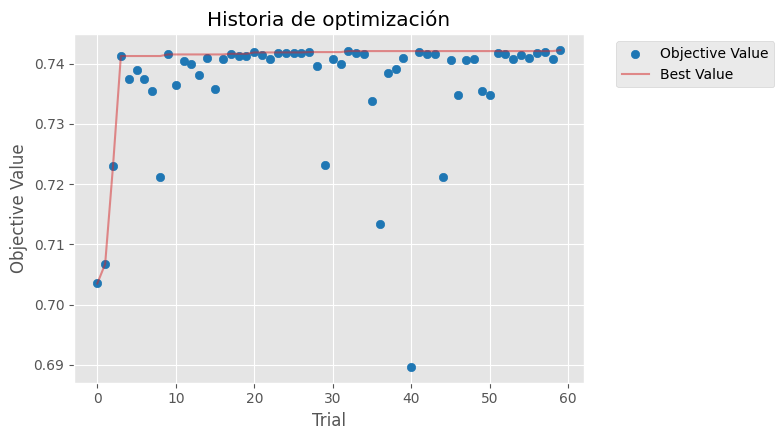

/tmp/ipykernel_243018/4072551696.py:12: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = plot_param_importances(study)


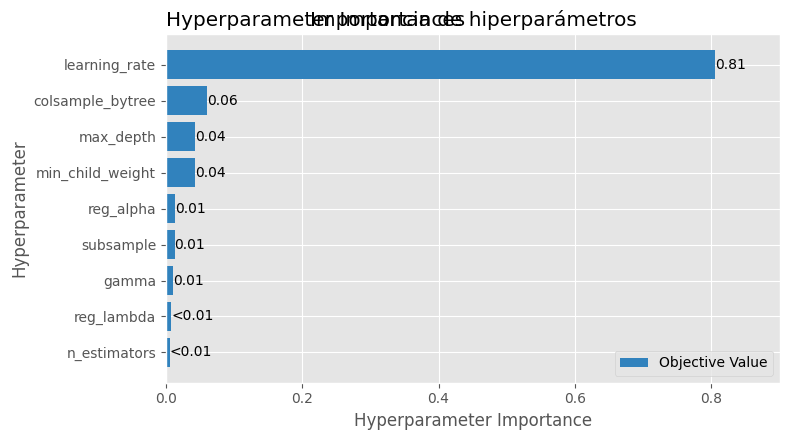

In [4]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (plot_optimization_history,
                                             plot_param_importances)

# Las funciones matplotlib de Optuna crean su propia figura y devuelven el Axes
# (no aceptan ax=). Las llamamos por separado.
ax1 = plot_optimization_history(study)
ax1.set_title("Historia de optimización")
ax1.figure.set_size_inches(8, 4.5)
plt.tight_layout(); plt.show()

ax2 = plot_param_importances(study)
ax2.set_title("Importancia de hiperparámetros")
ax2.figure.set_size_inches(8, 4.5)
plt.tight_layout(); plt.show()

## 4 · Modelo tuneado: evaluación con los dos protocolos

Reconstruimos el XGBoost con los mejores hiperparámetros y lo evaluamos con la
**misma** función del baseline (GroupKFold sobre el train-pool + OOT externo), para que la comparación
contra el XGBoost sin tunear sea directa.

In [5]:
def top_decile_lift(yt, p):
    k = max(len(yt) // 10, 1)
    sel = np.argsort(-p)[:k]
    return yt[sel].mean() / yt.mean()


def make_tuned_xgb(params):
    spw_train = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()
    return XGBClassifier(
        **params, scale_pos_weight=spw_train, eval_metric="logloss",
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)


def eval_model(model):
    # --- Validación interna: GroupKFold OOF SOBRE EL TRAIN-POOL (bucle interno) ---
    oof = np.zeros(len(yp))
    for tr, va in gkf_folds:
        spw = (yp[tr] == 0).sum() / (yp[tr] == 1).sum()
        m = make_tuned_xgb(study.best_params); m.set_params(scale_pos_weight=spw)
        m.fit(Xp.iloc[tr], yp[tr])
        oof[va] = m.predict_proba(Xp.iloc[va])[:, 1]
    cv_auc = roc_auc_score(yp, oof); cv_ap = average_precision_score(yp, oof)
    cv_lift = top_decile_lift(yp, oof)
    # --- OOT: bucle externo, test aislado (no visto en el tuning) ---
    model.fit(X[train_mask], y[train_mask])
    p = model.predict_proba(X[test_mask])[:, 1]; yt = y[test_mask]
    pr = (p >= 0.5).astype(int)
    dft = df[test_mask].copy(); dft["p"] = p
    aucs = [roc_auc_score(g["churn"], g["p"]) for _, g in
            dft.groupby(dft["mes_obs"].dt.strftime("%Y-%m")) if g["churn"].nunique() > 1]
    return {
        "cv_AUC": cv_auc, "cv_PRAUC": cv_ap, "cv_lift10": cv_lift,
        "oot_AUC": roc_auc_score(yt, p), "oot_AUCstd": np.std(aucs),
        "oot_F1": f1_score(yt, pr, zero_division=0),
        "oot_prec": precision_score(yt, pr, zero_division=0),
        "oot_rec": recall_score(yt, pr),
        "oot_lift10": top_decile_lift(yt, p),
    }


tuned = make_tuned_xgb(study.best_params)
metrics_tuned = eval_model(tuned)
pd.Series(metrics_tuned).round(4)

cv_AUC        0.7422
cv_PRAUC      0.5317
cv_lift10     1.9944
oot_AUC       0.7648
oot_AUCstd    0.0182
oot_F1        0.5525
oot_prec      0.4289
oot_rec       0.7762
oot_lift10    2.4377
dtype: float64

## 5 · Comparación: baseline vs tuneado

XGBoost baseline tomado de la síntesis de `01_modelos_baseline.ipynb`.

La comparación se hace en **OOT** (la métrica externa honesta de ambos modelos). La validación interna del tuneado se reporta aparte: no es comparable con el GroupKFold full-data del baseline.

In [6]:
# El baseline (sin tunear) y el tuneado se comparan en OOT, que para AMBOS es la
# métrica externa honesta. (La validación interna del tuneado no es comparable con
# el GroupKFold full-data del baseline, así que se reporta aparte.)
baseline_oot = {"oot_AUC": 0.7540, "oot_AUCstd": 0.0160, "oot_F1": 0.5260,
                "oot_prec": 0.4130, "oot_rec": 0.7238, "oot_lift10": 2.2943}
tuned_oot = {k: metrics_tuned[k] for k in baseline_oot}
cmp = pd.DataFrame({"XGB baseline": baseline_oot, "XGB tuneado": tuned_oot}).T
cmp.loc["Δ"] = cmp.loc["XGB tuneado"] - cmp.loc["XGB baseline"]
print("Comparación en OOT (test externo, NO visto durante el tuning):")
print(cmp.round(4).to_string())
print(f"\nValidación interna del modelo tuneado (GroupKFold sobre train-pool):")
print(f"  AUC {metrics_tuned['cv_AUC']:.4f} | PR-AUC {metrics_tuned['cv_PRAUC']:.4f}"
      f" | lift decil {metrics_tuned['cv_lift10']:.4f}")

Comparación en OOT (test externo, NO visto durante el tuning):
              oot_AUC  oot_AUCstd  oot_F1  oot_prec  oot_rec  oot_lift10
XGB baseline   0.7540      0.0160  0.5260    0.4130   0.7238      2.2943
XGB tuneado    0.7648      0.0182  0.5525    0.4289   0.7762      2.4377
Δ              0.0108      0.0022  0.0265    0.0159   0.0524      0.1434

Validación interna del modelo tuneado (GroupKFold sobre train-pool):
  AUC 0.7422 | PR-AUC 0.5317 | lift decil 1.9944


## 6 · Persistir el ganador

Guardamos los mejores hiperparámetros (`xgboost_best_params.json`) y el modelo
entrenado sobre el train OOT (`models/xgboost_tuned.joblib`) para que
`06_evaluation` los cargue sin reentrenar. El JSON deja registro auditable de la
configuración exacta usada.

In [7]:
import joblib

params_path = base / "05_modelling" / "xgboost_best_params.json"
with open(params_path, "w") as f:
    json.dump({"best_params": study.best_params,
               "best_value_cv_auc_trainpool": study.best_value,
               "oot_auc": metrics_tuned["oot_AUC"],
               "n_trials": N_TRIALS, "random_state": RANDOM_STATE}, f, indent=2)
print(f"hiperparámetros → {params_path}")

models_dir = base / "models"; models_dir.mkdir(exist_ok=True)
model_path = models_dir / "xgboost_tuned.joblib"
joblib.dump(tuned, model_path)   # `tuned` quedó fit sobre train OOT en la sec. 4
print(f"modelo → {model_path}")

hiperparámetros → /home/carlos/projects/glamour/customer-churn-prediction/05_modelling/xgboost_best_params.json
modelo → /home/carlos/projects/glamour/customer-churn-prediction/models/xgboost_tuned.joblib


## 7 · Síntesis

_(Completar tras ejecutar.)_

- Mejor AUC GroupKFold OOF: **`study.best_value`**.
- Δ vs baseline en ambos protocolos: ver tabla de la sec. 5.
- Lectura esperada: ganancia marginal acotada por el **techo de señal** (~0.77);
  el valor del tuning está tanto en el AUC como en la **estabilidad temporal**
  (`oot_AUCstd`) y la **regularización** (menor riesgo de sobreajuste a vendedoras
  muy activas).

**Próximo paso:** evaluación final en `06_evaluation` — curvas PR/ROC, elección del
punto operativo (recall/precision para la lista de retención), lift por decil e
interpretabilidad con **SHAP**, cargando `models/xgboost_tuned.joblib`.